## Criteria for Resonance Capture and Stability

### <u>Adiabadicity criterion</u>

#### From Lin et al. (2025)

"Relatively slow migration is a necessary resonant capture condition. When the planets undergo fast convergent migration, they directly bypass the resonance before the eccentricities reach their equilibrium values."

For $j$:$j-1$ resonance, the resonance trapping criterion of slow migration for $q \ll 1$ is 
$$\tau_m > \frac{1}{n_1 ( 3(k-1))^{1/3}} \frac{1}{(\mu_2 \alpha f)^{4/3}}$$
where $\mu_i=m_i/M$ and $q=m_1/m_2$. Small $e$'s are assumed.

#### From Batygin & Morbidelli (2026)

In the limit of compact orbits, for $k$:$k-1$ resonance,
$$\frac{1}{\tau_a \Omega} \lesssim \frac{5\pi}{8}\left(\frac{5}{36k^5(k-1)^{2/3}}\right)^{1/3} \left(\frac{M}{m_1+m_2}\right)^{4/3}$$

#### From Batygin (2015)
Additionally, consider Eq. 43 in: [Batygin (2015)](https://arxiv.org/pdf/1505.01778)

### <u>Eccentricity criterion</u>

#### From Batygin & Morbidelli (2026)

Orbits must possess sufficiently low eccentricities, which is guaranteed due to $e$ damping in a protoplanetary disk.

### <u>Dissipative stability criterion</u>

#### From Batygin & Morbidelli (2026)

"In resonance, convergence migration excites $e$ while disk tides damp it, and long-lived trapping requires the existence of a fixed point in which these effects balance. As such, the resonant forcing must be sufficiently strong to offset $e$ damping... if $e$ damping is too strong relative to the resonant forcing, no stationary resonant equilibrium exists."

$$\frac{1}{\tau_a \Omega} \lesssim \frac{m_2}{M} \sqrt{\frac{32k^3 (1+\zeta) (\zeta \, \mathcal{K_1} + \mathcal{K_2})}{25\mathcal{K_1}\mathcal{K_2}}}$$
where $\mathcal{K_j} = \tau_a/\tau_{e_j}$

### <u>Overstability criterion</u>

#### From Deck & Batygin (2015)
For $m+1\text{:}m$ resonance, the condition for instability is (Eq. 15):
$$\epsilon_p < \epsilon_{p, \rm crit} \equiv \frac{3pm}{\mathcal{B}2^{3/2}} \frac{\tau_e}{\tau_{a,e}} \frac{(1+\zeta)^2}{\left(m(\zeta+1) + p\frac{\tau_e}{\tau_{a,e}}\right)}^{3/2} \left(\frac{\tau_e}{\tau_a}\right)^{3/2}$$

where 
$$\epsilon_p = \frac{m_1+m_2}{M}$$
$$\mathcal{B} \approx 0.8m$$
$$R\equiv \frac{|f|}{g-\delta_{m,2}\alpha_{\rm res}}$$
$$\alpha_{\rm res} = \frac{a_1}{a_2} = \left(\frac{k-1}{k}\right)^{2/3}$$
$$\tau_a = \left(\frac{1}{\tau_{a_2}} - \frac{1}{\tau_{a_1}} \right)^{-1}$$
$$\tau_e = \left(\frac{1}{\tau_{e_1}} + \frac{\zeta}{\tau_{e_2}} \right)^{-1}$$
$$\tau_{a,e} = \left(\frac{1}{\tau_{e_1}} - \frac{\zeta^2 \alpha_{\rm res}}{R^2 \tau_{e_2}} \right)^{-1}$$
$$\zeta = \frac{m_1}{m_2}$$

See Eq. 15 in [Deck & Batygin (2015)](https://arxiv.org/pdf/1506.01382). Additionally, consider the escape criterion in Eq. 21.

#### From Batygin & Morbidelli (2026)

For low values of $\mathcal{K}$, resonance locking gives way to the onset of overstability of resonant librations. The instability criterion is

$$\left[ \frac{\zeta (k(1+\zeta)-2\zeta)}{1-\zeta} \frac{\chi_a}{\chi_e}\right]^{3/2} < \frac{15}{32} \frac{1-\zeta^2}{M/m_2}\left(\frac{h}{r}\right)^3$$
where $h/r$ is the aspect ratio, $\chi_a = 1/(2.7+1.1s)$, $\chi_e = 1/0.780$. However, there may be a typo here where it should be $m_2/M$ instead of $M/m_2$.

### <u>Damping timescales</u>

#### From Batygin & Morbidelli (2026)
$$\tau_{a_j} = \chi_a \left( \frac{m_j}{M} \frac{\Sigma a_j^2}{M} \left(\frac{h}{r}\right)^{-2} \Omega_j \right)^{-1}$$
$$\tau_{e_j} = \frac{\chi_e}{\chi_a} \left(\frac{h}{r}\right)^{2} \tau_{a_j}$$
where $h/r$ is the aspect ratio, $\chi_a = 1/(2.7+1.1s)$, $\chi_e = 1/0.780$.

### Plotting the above criteria

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl
import astropy.units as u

def plot_prettier(dpi=200, fontsize=8, usetex=False): 
    '''
    Make plots look nicer compared to Matplotlib defaults
    Parameters: 
        dpi - int, "dots per inch" - controls resolution of PNG images that are produced
                by Matplotlib
        fontsize - int, font size to use overall
        usetex - bool, whether to use LaTeX to render fonds of axes labels 
                use False if you don't have LaTeX installed on your system
    '''
    plt.rcParams['figure.dpi']= dpi
    plt.rc("savefig", dpi=dpi)
    plt.rc('font', size=fontsize)
    plt.rc('xtick', direction='in') 
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=5) 
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5) 
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [2., 2.])
    if usetex:
        plt.rc('text', usetex=usetex)
    else:
        plt.rcParams['mathtext.fontset'] = 'cm'
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plot_prettier()

# === UNIT CONVERSIONS ===
AU = u.AU.to(u.cm)    
G = 4*np.pi**2 # in yr, AU, Msun
Msun = u.Msun.to(u.g) 
yr = u.yr.to(u.s)    
r_earth = u.earthRad.to(u.AU)
m_earth = u.Mearth.to(u.Msun)
r_sun = u.Rsun.to(u.AU) 

with open("fg_library.pkl", "rb") as f:
        fg_lib = pkl.load(f)

f, g = fg_lib[(3,2)]
# print(f,g)

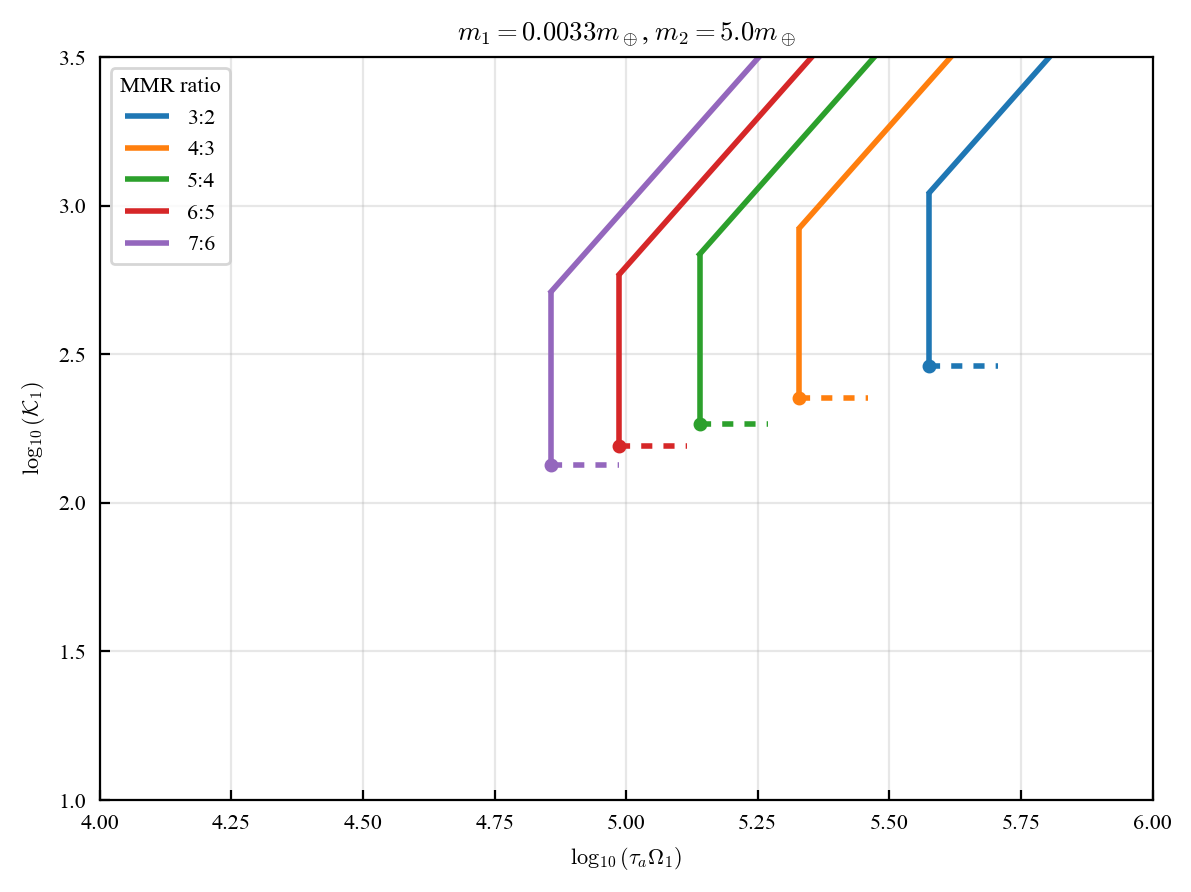

In [28]:
m1 = 0.0033 * m_earth
m2 = 5 * m_earth
M = 1.0

zeta = m1 / m2
s = 1
chi_a = 1 / (2.7 + 1.1 * s)
chi_e = 1 / 0.780

def adiabaticity_crit(k):
    """
    Returns C_k for:

        1 / (tau_a * Omega_1) <= C_k
    """
    return (
        (5 * np.pi / 8)
        * (5 / (36 * k**5 * (k - 1)**(2/3)))**(1/3)
        * (M / (m1 + m2))**(4/3)
    )

def dissipative_crit(k, K1, K2):
    """
    Returns C_k for:

        1 / (tau_a * Omega_1) <= C_k
    """
    return (
        (m2 / M)
        * np.sqrt(
            32 * k**3 * (1 + zeta) * (zeta * K1 + K2)
            / (25 * K1 * K2)
        )
    )

def K2_from_K1(k, K1):
    """
    K2 = K1 * (m2/m1) * (a2/a1)^2 * (Omega2/Omega1)

    For k:k-1 resonance:
        a1/a2 = ((k-1)/k)^(2/3)
        Omega2/Omega1 = (k-1)/k
    """
    alpha = ((k - 1) / k)**(2/3)  # a1/a2

    return K1 * (m2 / m1) * alpha**(-2) * ((k - 1) / k) # note that this assumes Sigma is the same for both

def migration_timescale_ratio(k):
    """
    R = tau_a1 / tau_a2.

    Assuming same Sigma and h/r for both planets:

        R = (m2/m1) * (a2/a1)^2 * (Omega2/Omega1)
    """
    alpha = ((k - 1) / k)**(2/3)  # a1/a2

    return (m2 / m1) * alpha**(-2) * ((k - 1) / k)

def h_over_r_from_K1(k, K1):
    """
    K1 = (chi_a/chi_e) * (h/r)^(-2) / (R - 1)
    """
    R = migration_timescale_ratio(k)

    return np.sqrt((chi_a / chi_e) / (K1 * (R - 1)))

def overstability_K1_crit(k):
    """
    Finds K1 at the overstability threshold.

    Instability occurs when:

        [ zeta * (k(1+zeta)-2zeta)/(1-zeta) * chi_a/chi_e ]^(3/2)
        < (15/32) * (1-zeta^2)/m2 * (h/r)^3

    This gives a critical h/r, which is converted to K1.
    Low K1 corresponds to larger h/r, so overstability occurs below this K1.
    """
    R = migration_timescale_ratio(k)

    lhs_base = (
        zeta
        * (k * (1 + zeta) - 2 * zeta)
        / (1 - zeta)
        * (chi_a / chi_e)
    )

    A = lhs_base**(3/2)
    B = (15 / 32) * (1 - zeta**2) / m2

    h_crit = (A / B)**(1/3)

    K1_crit = (chi_a / chi_e) / (h_crit**2 * (R - 1))

    return K1_crit

x_min, x_max = 4, 6
y_min, y_max = 1, 3.5

logK1 = np.linspace(y_min, y_max, 600)
K1 = 10**logK1

fig, ax = plt.subplots(figsize=(6, 4.5))

for k in range(3, 8):
    color = f"C{k-3}"

    K2 = K2_from_K1(k, K1)

    C_adia = adiabaticity_crit(k)
    C_diss = dissipative_crit(k, K1, K2)

    # Since x = log10(tau_a Omega_1),
    # 1/(tau_a Omega_1) <= C means x >= -log10(C).
    x_adia = np.log10(C_adia)
    x_diss = -np.log10(C_diss)

    transition_idx = np.argmax(x_diss >= x_adia)

    if x_diss[transition_idx] < x_adia:
        y_transition = y_max
    else:
        y_transition = logK1[transition_idx]

    # Overstability threshold: unstable below this K1.
    K1_over = overstability_K1_crit(k)
    y_over = np.log10(K1_over)

    y_adia_start = max(y_min, y_over)

    # Adiabaticity: vertical segment, after overstability stops dominating.
    if y_adia_start < y_transition:
        ax.vlines(
            x=x_adia,
            ymin=y_adia_start,
            ymax=min(y_transition, y_max),
            lw=2,
            color=color,
            label=rf"{k}:{k-1}"
        )

    # Dissipative stability: slanted high-K1 segment.
    mask = logK1 >= max(y_transition, y_over)

    ax.plot(
        x_diss[mask],
        logK1[mask],
        lw=2,
        color=color,
    )

    # Overstability: horizontal low-K1 boundary.
    if y_min <= y_over <= y_max:
        ax.hlines(
            y=y_over,
            xmin=x_adia,
            xmax=x_adia+0.13,
            lw=2,
            color=color,
            ls=":"
        )

        ax.plot(x_adia, y_over, "o", color=color, ms=4)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_xlabel(r"$\log_{10}(\tau_a \Omega_1)$")
ax.set_ylabel(r"$\log_{10}(\mathcal{K}_1)$")

ax.legend(title="MMR ratio")
ax.set_title(rf"$m_1={m1/m_earth:.4f} m_\oplus$, $m_2={m2/m_earth} m_\oplus$")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

### (A previous attempt)

In [26]:
# Obtain timescales

from timescales import tau_t1_mig, tau_gas

# === PARAMETERS ===
planets = {
    "name": ['planet b', 'planet c', 'planet d'],
    "m_vals": [4, 8, 5], # [m_earth]
    "a_vals": [0.107, 0.2, 0.3], # [AU]
    "r_vals": [10, 10, 10] # [r_earth]; twice the current values
}

num_pl = 3
num_em = 1
num_ptsml = 1

rock_names = planets['name'][:num_pl] + [f"embryo {i}" for i in range(num_em)] + [f"ptsml {i}" for i in range(num_ptsml)]
    
# Setting up em/ptsml disk
m_em = 0.03 # [m_earth]
r_em = 0.3 # [r_earth]
m_ptsml = 0.000000075 # [m_earth]
r_ptsml = (100*1e5/AU)/r_earth # 100 km in [r_earth]
small_body_a_vals = np.linspace(0.4, 0.9, num_em+num_ptsml) # equally spaced locations in disk range
em_indices = np.round(np.linspace(0, len(small_body_a_vals) - 1, num=num_em)).astype(int) # picks num_em equally spaced indices
em_a_vals = small_body_a_vals[em_indices]
ptsml_a_vals = np.delete(small_body_a_vals, em_indices)
    
# Combine values for planets, ems, ptsmls
m_vals = np.array(planets['m_vals'][:num_pl] + [m_em]*num_em + [m_ptsml]*num_ptsml) * m_earth
r_vals = np.array(planets['r_vals'][:num_pl] + [r_em]*(num_em) + [r_ptsml]*num_ptsml) * r_earth
m_star = 1. # Msun
r_star = 1.5 * r_sun
a_vals = np.concatenate((planets['a_vals'][:num_pl], em_a_vals, ptsml_a_vals)) # Initial a_vals
    
# Full parameter space
Sigma_1au = 1700
h_1au = 0.03
alpha = 1
beta = 0                                  # Converted to Msun/AU^2 from g/cm^2
tau_a = 1/(2.7+1.1*alpha) / m_vals[0] / (Sigma_1au*AU**2 / Msun) * h_1au**2 / (2*np.pi) # for a = 1

parameters = {"m_vals": m_vals,
              "m_star": m_star,
              "r_vals": r_vals,
              "r_star": r_star,
              "a_vals": a_vals,
              "num_pl": num_pl,
              "num_em": num_em,
              "num_ptsml": num_ptsml,
              "ide_position": 0.1,
              "ide_width": 0.1 * h_1au**beta,
              "Sigma_1au": Sigma_1au,
              "h_1au": h_1au,
              "alpha": alpha,
              "beta": beta,
              "m_em": m_em,
              "r_em": r_em,
              "m_ptsml": m_ptsml,
              "r_ptsml": r_ptsml,
            } 

import rebound
# Create the simulation
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')
sim.add(m=parameters["m_star"], r=parameters["r_star"], hash='star')

# Add planet 1
sim.add(
    m=parameters['m_vals'][0], 
    r=parameters['r_vals'][0], 
    a=parameters['a_vals'][0], 
    primary=sim.particles[0], 
    e=0,
    inc=0,
)

# Add planet 2
sim.add(
    m=parameters['m_vals'][1], 
    r=parameters['r_vals'][1], 
    a=parameters['a_vals'][1], 
    primary=sim.particles[0], 
    e=0,
    inc=0,
)

# Add ptsml
sim.add(
    m=parameters['m_vals'][-1], 
    r=parameters['r_vals'][-1], 
    a=parameters['a_vals'][-1], 
    primary=sim.particles[0], 
    e=0,
    inc=0,
)

ps = sim.particles
ta_p1, te_p1 = -np.array(tau_t1_mig(ps[1], parameters))[0:2]
ta_p2, te_p2 = -np.array(tau_t1_mig(ps[2], parameters))[0:2]
ta_ptsml, te_ptsml = -np.array(tau_t1_mig(ps[-1], parameters))[0:2]
print('planet 1', int(ta_p1), int(te_p1))
print('planet 2', int(ta_p2), int(te_p2))
print(f'ptsml    {int(ta_ptsml):.3g}, {int(te_ptsml):.3g}')

planet 1 13392 23
planet 2 3667 16
ptsml    8.31e+11, 3.64e+09


In [ ]:
def get_crit_ep(k, Sigma_1au, h_1au):
    # Batygin: k:k-1, so 7:6 MMR has k=7
    # Deck: m+1:m, so 7:6 MMR has m=6
    m = k-1
    print(f"{k}:{k-1} MMR")

    B = 0.8*m
    p = 1 # coupling parameter

    m1 = m_ptsml*m_earth
    m2 = 5*m_earth
    zeta = m1/m2
    print(f"zeta: {zeta:.5f}")

    alpha = 1
    print(f"Sigma_1au: {Sigma_1au}, h_1au: {h_1au}")

    chi_a = 1/(2.7+1.1*alpha)
    chi_e = 1/0.780

    alphares = ((k-1)/k)**(2/3)
    print(f"α_res: {alphares:.3f}")
    with open("fg_library.pkl", "rb") as f:
        fg_lib = pkl.load(f)

    f, g = fg_lib[(k, k-1)]

    R = abs(f)/g # if not 2:1

    # Change these
    ta1, te1 = ta_p1, te_p1 # ta_ptsml, te_ptsml # inner
    ta2, te2 = ta_p2, te_p2       # outer

    ta = (1/ta2 - 1/ta1)**-1
    te = (1/te1 + zeta/te2)**-1
    tae = (1/te1 - zeta**2 * alphares / (R**2 * te2))**-1 

    ep_p = m1+m2
    ep_p_crit = (3*p*m)/(B * 2**1.5) * te/tae * (1+zeta)**2 / (m*(zeta+1) + p*te/tae)**1.5 * (te/ta)**1.5
    print(f"ε_p: {ep_p:.4g}") # Overstable if over ep_p_crit
    print(f"ε_p,crit: {ep_p_crit:.4g}") 
    if ep_p < ep_p_crit:
        print("ep_p < ep_p_crit")
    else:
        print("ep_p > ep_p_crit")
        
get_crit_ep(4, 1700, 0.03)

4:3 MMR
zeta: 0.00066
Sigma_1au: 1700, h_1au: 0.03
α_res: 0.825
ε_p: 1.503e-05
ε_p,crit: 1.28e-05
ep_p > ep_p_crit


In [ ]:
print(f"ta1 = {ta1:.3e}")
print(f"ta2 = {ta2:.3e}")
print(f"ta  = {ta:.3e}")

print(f"te1 = {te1:.3e}")
print(f"te2 = {te2:.3e}")
print(f"te  = {te:.3e}")

print(f"tae = {tae:.3e}")

print(f"te/ta  = {te/ta:.3e}")
print(f"te/tae = {te/tae:.3e}")

ta1 = 8.396e+11
ta2 = 1.071e+04
ta  = 1.071e+04
te1 = 1.336e+09
te2 = 1.882e+01
te  = 2.851e+04
tae = -2.893e+07
te/ta  = 2.661e+00
te/tae = -9.853e-04
